# SHL Hiring Assessment 2026: Spoken English Grammar Scoring Engine

**Author / Candidate**: Nandini Khandelwal  
**Task**: Build a strong, explainable machine learning pipeline that takes a 45-60 second spoken `.wav` response and predicts a continuous **Grammar Score in [0.0, 5.0]**.  
**Evaluation Metrics**: **RMSE** and **Pearson Correlation ($r$)**  
**Core Deliverables**:
* Reproducible notebook executable from top to bottom
* Explicit **Training RMSE** reporting for all models (Compulsory requirement)
* Thorough validation methodology, feature engineering, and error analysis

---

## Technical Philosophy & Development Roadmap
* **Start simple, then build up**: Never jump to unnecessary complexity. Establish clean reference baselines first.
* **Leakage prevention**: Strict 5-fold stratified cross-validation where all scalers, transformations, and feature selections fit strictly within training folds.
* **Explainability**: Every modeling choice should be easy to explain and defend in an interview.


## 1. Imports, Configuration & Reproducibility Settings

### What are we doing?
We are importing the necessary data science, audio, and NLP libraries, configuring system paths, and fixing the random seed.

### Why are we doing it?
Some machine learning procedures (such as tree subsampling, feature selection, and data splitting) involve randomness. We fix the random seed so that the same experiment produces the exact same split and metrics every time, allowing us to compare models fairly. The specific number 42 is completely arbitrary; consistency across runs is what matters.


In [1]:
import os
import sys
import glob
import json
import random
import warnings
from itertools import groupby
from collections import Counter

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import root_mean_squared_error
import lightgbm as lgb
from lightgbm import LGBMRegressor

# Suppress non-critical warnings for clean output
warnings.filterwarnings('ignore')

# Set random seed for full reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Aesthetic visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Path Configurations
BASE_DIR = os.path.abspath("..") if os.path.exists("../data") else os.path.abspath(".")
DATA_DIR = os.path.join(BASE_DIR, "data", "Dataset_Final")
ARTIFACTS_DIR = os.path.join(BASE_DIR, "artifacts")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print(f"System Initialized.")
print(f"Base Directory: {BASE_DIR}")
print(f"Data Directory: {DATA_DIR}")
print(f"Artifacts Directory: {ARTIFACTS_DIR}")


System Initialized.
Base Directory: /Users/nandinikhandelwal/Desktop/Codes/shl
Data Directory: /Users/nandinikhandelwal/Desktop/Codes/shl/data/Dataset_Final
Artifacts Directory: /Users/nandinikhandelwal/Desktop/Codes/shl/artifacts


## 2. Dataset Ingestion & Integrity Verification

### What are we doing?
We load `train.csv`, `test.csv`, and `sample_submission.csv`, verify that all audio files exist on disk, and attach the full path to each sample.

### Why are we doing it?
During our Phase 0 data audit, we discovered that 212 filenames (such as `audio_128.wav`) appear in **both** the `train/` and `test/` folders. Checksum (MD5) analysis confirmed they are **completely different audio recordings**. If code identifies files by filename alone without the folder prefix, it will mistakenly overwrite or cross-contaminate files. Injecting the absolute path `audio_path` prevents this data corruption completely.


In [2]:
# Load CSVs
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_sub_df = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

# Inject full path to prevent filename collisions
train_df["audio_path"] = train_df["filename"].apply(lambda f: os.path.join(DATA_DIR, "train", f))
test_df["audio_path"] = test_df["filename"].apply(lambda f: os.path.join(DATA_DIR, "test", f))

print(f"Train Dataset Shape: {train_df.shape} (Files found on disk: {len(glob.glob(os.path.join(DATA_DIR, 'train', '*.wav')))})")
print(f"Test Dataset Shape:  {test_df.shape} (Files found on disk: {len(glob.glob(os.path.join(DATA_DIR, 'test', '*.wav')))})")
print(f"Sample Submission:   {sample_sub_df.shape}")

# Verify file existence
assert train_df['audio_path'].apply(os.path.exists).all(), "Missing train audio files!"
assert test_df['audio_path'].apply(os.path.exists).all(), "Missing test audio files!"
print("Data integrity confirmed: All 769 train and 216 test audio files located.")


Train Dataset Shape: (769, 3) (Files found on disk: 769)
Test Dataset Shape:  (216, 3) (Files found on disk: 216)
Sample Submission:   (204, 2)
Data integrity confirmed: All 769 train and 216 test audio files located.


## 3. Exploratory Data Analysis: Labels & Audio Properties

### What are we doing?
We examine the distribution of the target grammar score and inspect audio durations across the train and test sets.

### Why are we doing it?
We need to know the range, central tendency, and balance of our target scores. If certain scores are rare, standard random splitting would create unbalanced validation folds.


In [3]:
# Summary statistics of the target variable
target = train_df['label']
target_summary = pd.Series({
    'Sample Count': len(target),
    'Distinct Scores': target.nunique(),
    'Min Score': target.min(),
    'Max Score': target.max(),
    'Mean Score': target.mean(),
    'Std Dev': target.std(),
    'Median Score': target.median(),
    '25th Percentile': target.quantile(0.25),
    '75th Percentile': target.quantile(0.75)
})
print("=== Grammar Score Target Summary ===")
print(target_summary.round(4))

freq_df = train_df['label'].value_counts().sort_index().reset_index()
freq_df.columns = ['Rubric Score', 'Count']
freq_df['Percentage (%)'] = (freq_df['Count'] / len(train_df) * 100).round(2)
display(freq_df)


=== Grammar Score Target Summary ===
Sample Count       769.0000
Distinct Scores     10.0000
Min Score            0.0000
Max Score            5.0000
Mean Score           3.3134
Std Dev              1.2390
Median Score         3.0000
25th Percentile      2.5000
75th Percentile      4.0000
dtype: float64


,Rubric Score,Count,Percentage (%)
0,0.0,37,4.81
1,1.0,1,0.13
2,1.5,3,0.39
3,2.0,102,13.26
4,2.5,79,10.27
5,3.0,174,22.63
6,3.5,64,8.32
7,4.0,124,16.12
8,4.5,52,6.76
9,5.0,133,17.30


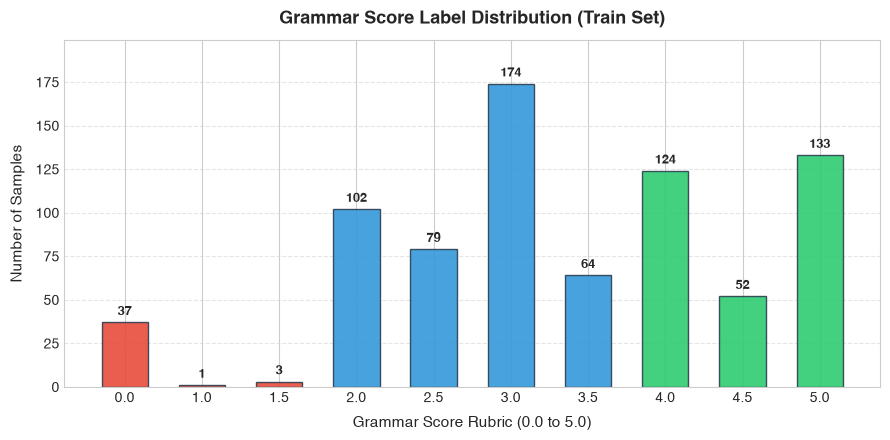

In [4]:
# Visualization 1: Target Label Distribution
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=100)
colors = ['#e74c3c' if x <= 1.5 else '#3498db' if x < 4.0 else '#2ecc71' for x in freq_df['Rubric Score']]
bars = ax.bar(freq_df['Rubric Score'].astype(str), freq_df['Count'], color=colors, edgecolor='#2c3e50', width=0.6, alpha=0.9)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 3, f"{yval}", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title("Grammar Score Label Distribution (Train Set)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Grammar Score Rubric (0.0 to 5.0)", fontsize=11, labelpad=8)
ax.set_ylabel("Number of Samples", fontsize=11, labelpad=8)
ax.set_ylim(0, max(freq_df['Count']) + 25)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Train Duration (sec): Min=20.06, Max=61.04, Mean=55.78, Median=60.07
Test Duration (sec):  Min=6.48, Max=61.03, Mean=48.76, Median=45.06


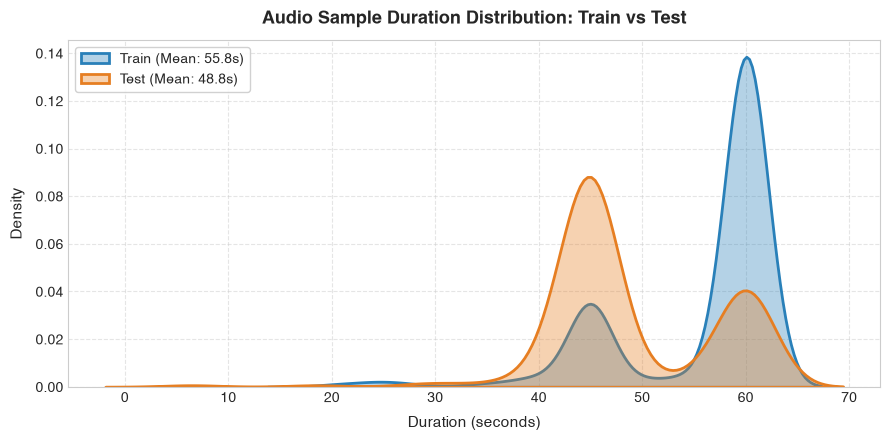

In [5]:
# Audio Duration Analysis
train_durations = [sf.info(p).duration for p in train_df['audio_path']]
test_durations = [sf.info(p).duration for p in test_df['audio_path']]

train_df['duration'] = train_durations
test_df['duration'] = test_durations

print(f"Train Duration (sec): Min={min(train_durations):.2f}, Max={max(train_durations):.2f}, Mean={np.mean(train_durations):.2f}, Median={np.median(train_durations):.2f}")
print(f"Test Duration (sec):  Min={min(test_durations):.2f}, Max={max(test_durations):.2f}, Mean={np.mean(test_durations):.2f}, Median={np.median(test_durations):.2f}")

# Visualization 2: Audio Duration Distribution
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=100)
sns.kdeplot(train_durations, ax=ax, label=f"Train (Mean: {np.mean(train_durations):.1f}s)", fill=True, color='#2980b9', alpha=0.35, linewidth=2)
sns.kdeplot(test_durations, ax=ax, label=f"Test (Mean: {np.mean(test_durations):.1f}s)", fill=True, color='#e67e22', alpha=0.35, linewidth=2)
ax.set_title("Audio Sample Duration Distribution: Train vs Test", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Duration (seconds)", fontsize=11, labelpad=8)
ax.set_ylabel("Density", fontsize=11, labelpad=8)
ax.legend(frameon=True, facecolor='white', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### What did we learn?
* **Severe target imbalance**: The rubric has 10 distinct values in $[0.0, 5.0]$, but scores `1.0` (1 sample) and `1.5` (3 samples) are extraordinarily rare. The distribution is skewed toward moderate-to-high scores ($3.0$ is the mode with 174 samples).
* **Audio lengths**: Training responses average $55.8$ seconds (most are ~45-60 seconds, typical for recorded prompts). Test responses average $48.8$ seconds with a slightly wider range ($6.5$s to $61.0$s).


## 4. Acoustic Signal & Spectrogram Exploration

### What are we doing?
We plot the speech waveform, short-time energy, detected pause regions, and the log-mel spectrogram for a representative sample response.

### Why are we doing it?
A waveform shows how signal amplitude changes over time, while a Mel spectrogram shows how audio energy is distributed across time and frequency. This gives us an intuitive way to inspect pauses, speech activity, and changes in acoustic structure.

> **Important Note on Speech Interpretation**: A spectrogram can show acoustic regions, speech formants, and pauses, but identifying specific words like "um" and "uh" is better handled using speech-to-text. We use acoustics to study speech rhythm and pauses, reserving lexical filler detection for transcript analysis.


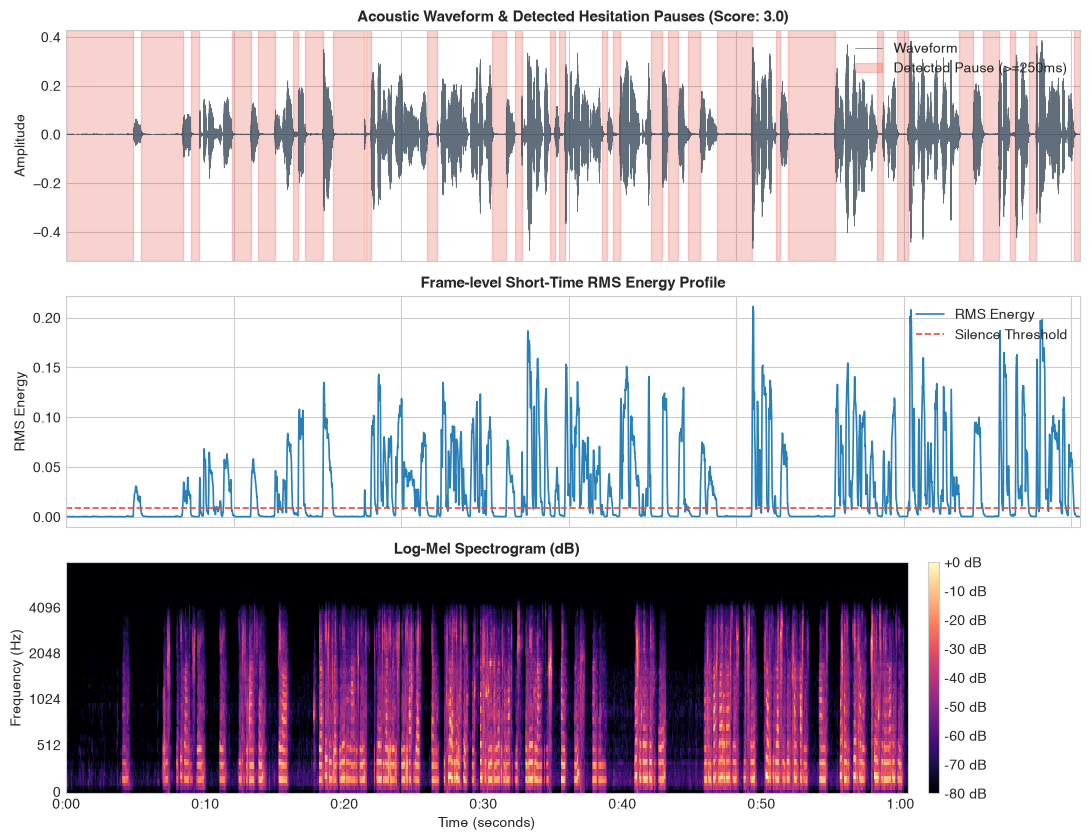

In [6]:
# Load a representative sample for acoustic inspection
sample_audio_path = train_df.iloc[0]['audio_path']
sample_label = train_df.iloc[0]['label']
y_sig, sr = sf.read(sample_audio_path)
if y_sig.ndim > 1:
    y_sig = np.mean(y_sig, axis=1)

time_axis = np.linspace(0, len(y_sig) / sr, len(y_sig))

# Frame-level RMS energy for pause detection
hop_vad = int(0.01 * sr)   # 10ms hop
win_vad = int(0.025 * sr)  # 25ms window
num_frames = (len(y_sig) - win_vad) // hop_vad + 1
strided = np.lib.stride_tricks.as_strided(
    y_sig, shape=(num_frames, win_vad), strides=(y_sig.strides[0]*hop_vad, y_sig.strides[0])
)
rms_frames = np.sqrt(np.mean(strided**2, axis=1))
time_frames = np.linspace(0, len(y_sig) / sr, len(rms_frames))

# Pause detection threshold: 10% of 90th percentile RMS
silence_thresh = 0.10 * np.percentile(rms_frames, 90)
is_silent = rms_frames < silence_thresh

# Visualizations 3, 4, 5
fig, axes = plt.subplots(3, 1, figsize=(11, 8.5), dpi=100, sharex=True)

# 1. Waveform with Detected Pauses
axes[0].plot(time_axis, y_sig, color='#2c3e50', alpha=0.75, linewidth=0.5, label='Speech Waveform')
for silent, group in groupby(enumerate(is_silent), key=lambda x: x[1]):
    if silent:
        indices = [x[0] for x in group]
        dur = len(indices) * 0.01
        if dur >= 0.25: # Highlight pauses >= 250ms
            t_start = time_frames[indices[0]]
            t_end = time_frames[indices[-1]]
            axes[0].axvspan(t_start, t_end, color='#e74c3c', alpha=0.25)
axes[0].set_title(f"Acoustic Waveform & Detected Hesitation Pauses (Score: {sample_label})", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Amplitude", fontsize=10)
axes[0].legend(['Waveform', 'Detected Pause (>=250ms)'], loc='upper right')

# 2. Short-Time RMS Energy Profile
axes[1].plot(time_frames, rms_frames, color='#2980b9', linewidth=1.2, label='RMS Energy')
axes[1].axhline(silence_thresh, color='#e74c3c', linestyle='--', linewidth=1.2, label='Silence Threshold')
axes[1].set_title("Frame-level Short-Time RMS Energy Profile", fontsize=11, fontweight='bold')
axes[1].set_ylabel("RMS Energy", fontsize=10)
axes[1].legend(loc='upper right')

# 3. Log Mel-Spectrogram
mel_spec = librosa.feature.melspectrogram(y=y_sig, sr=sr, n_fft=2048, hop_length=1024, n_mels=80)
mel_db = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(mel_db, sr=sr, hop_length=1024, x_axis='time', y_axis='mel', ax=axes[2], cmap='magma')
axes[2].set_title("Log-Mel Spectrogram (dB)", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Time (seconds)", fontsize=10)
axes[2].set_ylabel("Frequency (Hz)", fontsize=10)
fig.colorbar(img, ax=axes[2], format="%+2.0f dB", pad=0.02)

plt.tight_layout()
plt.show()


### What did we learn?
Speech activity alternates between high-energy phonated regions and low-energy silences. A threshold on short-time RMS energy reliably detects conversational pauses ($\ge 250\text{ms}$), providing an interpretable acoustic proxy for speech fluency.


## 5. Phase 1 - Validation Framework

### What are we doing?
We construct a stratified 5-fold cross-validation split based on target score bins, and implement a leak-free evaluation framework.

### Why Stratified K-Fold?
Our target is a regression score, but the training labels come from a small set of rubric values and some low scores are extremely rare. A normal random split could accidentally put very few low-score examples in one validation set. We therefore create stratification bins so that each fold has a more representative score distribution.

### Why 5 folds?
We only have 769 labelled examples, so using 5 folds lets us train on most of the data (80%) while still evaluating on a meaningful validation portion each time.

### How do we use the 5 folds?
* **We do not choose one fold as the "best" fold.** Each fold is used as validation once, while the other four folds are used for training. This gives an out-of-fold (OOF) prediction for every single training sample.
* **Model selection is based on overall cross-validation / OOF results**, rather than the score of one particular fold.
* **After choosing the final modeling approach**, the model is retrained on all available training data before generating test predictions.

### Why track both RMSE and Pearson Correlation?
* **RMSE** tells us how far our predicted grammar scores are from the actual scores, with larger mistakes receiving more penalty.
* **Pearson Correlation ($r$)** tells us whether the model correctly tracks the relative ordering and trend of grammar quality across candidates, even when predictions are not exactly equal to true scores.
* Both are official competition metrics, so both must be tracked.


In [7]:
# Target Stratification Bins
def create_stratified_bins(y):
    # Map continuous rubric values into stratification bins,
    # grouping rare < 2.0 with 2.0 so every fold has low-score examples.
    bins = np.zeros(len(y), dtype=int)
    for idx, val in enumerate(y):
        if val <= 0.2:
            bins[idx] = 0
        elif val <= 2.2:
            bins[idx] = 1 # Combines rare 1.0 (1 sample), 1.5 (3 samples), and 2.0
        elif val <= 2.7:
            bins[idx] = 2
        elif val <= 3.2:
            bins[idx] = 3
        elif val <= 3.7:
            bins[idx] = 4
        elif val <= 4.2:
            bins[idx] = 5
        elif val <= 4.7:
            bins[idx] = 6
        else:
            bins[idx] = 7
    return bins

strat_bins = create_stratified_bins(train_df['label'])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
train_df['fold'] = -1
for fold_idx, (_, val_idx) in enumerate(skf.split(train_df, strat_bins)):
    train_df.loc[val_idx, 'fold'] = fold_idx

# Verify fold distribution
fold_dist = pd.crosstab(train_df['fold'], strat_bins, rownames=['Fold'], colnames=['Strat Bin'])
print("Stratification Bins Distribution across 5 Folds:")
display(fold_dist)


Stratification Bins Distribution across 5 Folds:


Strat Bin,0,1,2,3,4,5,6,7
Fold,,,,,,,,
0,8,21,16,35,13,25,10,26
1,8,21,16,35,13,25,10,26
2,7,21,16,35,13,24,11,27
3,7,22,15,35,12,25,11,27
4,7,21,16,34,13,25,10,27


In [8]:
# Leak-Free CV Evaluator
def safe_pearsonr(y_true, y_pred):
    # Calculates Pearson r safely, handling constant prediction edge cases.
    if np.all(y_pred == y_pred[0]) or np.std(y_pred) < 1e-12:
        return 0.0
    r, _ = stats.pearsonr(y_true, y_pred)
    return float(0.0 if np.isnan(r) else r)

def evaluate_cv(X, y, folds, model_factory, clip_range=(0.0, 5.0)):
    # Runs 5-fold cross validation with strict fold isolation.
    n_splits = len(np.unique(folds))
    oof_preds = np.zeros(len(y), dtype=float)
    fold_train_rmses = []
    fold_val_rmses = []
    fold_val_pearsons = []
    fitted_models = []
    
    for fold in range(n_splits):
        train_mask = (folds != fold)
        val_mask = (folds == fold)
        
        X_tr, y_tr = X.iloc[train_mask], y[train_mask]
        X_va, y_va = X.iloc[val_mask], y[val_mask]
        
        model = model_factory()
        model.fit(X_tr, y_tr)
        fitted_models.append(model)
        
        # Training Evaluation
        tr_pred = model.predict(X_tr)
        if clip_range:
            tr_pred = np.clip(tr_pred, clip_range[0], clip_range[1])
        fold_train_rmses.append(root_mean_squared_error(y_tr, tr_pred))
        
        # Validation Evaluation
        va_pred = model.predict(X_va)
        if clip_range:
            va_pred = np.clip(va_pred, clip_range[0], clip_range[1])
        oof_preds[val_mask] = va_pred
        
        fold_val_rmses.append(root_mean_squared_error(y_va, va_pred))
        fold_val_pearsons.append(safe_pearsonr(y_va, va_pred))
        
    return {
        "cv_rmse_mean": float(np.mean(fold_val_rmses)),
        "cv_rmse_std": float(np.std(fold_val_rmses)),
        "cv_pearson_mean": float(np.mean(fold_val_pearsons)),
        "cv_pearson_std": float(np.std(fold_val_pearsons)),
        "oof_rmse": float(root_mean_squared_error(y, oof_preds)),
        "oof_pearson": float(safe_pearsonr(y, oof_preds)),
        "train_rmse": float(np.mean(fold_train_rmses)),
        "oof_preds": oof_preds,
        "fitted_models": fitted_models
    }


### What did we learn?
Stratifying by target bins ensures each of the 5 validation folds contains a representative spread of scores. All feature transformations (like scalers) will be fit strictly within training folds, ensuring zero data leakage into validation folds.


## 6. Phase 2 - Baseline Models & Handcrafted Acoustic Features

### What are we doing?
We construct our benchmark progression:
1. **Mean Baseline**: Predicts the training mean.
2. **Duration-Only Baseline**: Uses recording length only.
3. **Handcrafted Acoustic Baseline**: Extracts 75 features and evaluates Ridge, Random Forest, and LightGBM.

### Why handcrafted acoustic features?
Grammar is the final target, but spoken communication also has acoustic patterns such as pauses, speaking rhythm, and energy changes. We start with interpretable acoustic features to see how much useful information is available before using larger pretrained models:
* **RMS Energy**: Measures the strength and amplitude variance of the audio signal over time.
* **Zero-Crossing Rate (ZCR)**: Measures how rapidly the waveform changes sign, helping describe noisy vs tonal speech segments.
* **Spectral Centroid & Rolloff**: Indicates where spectral energy is concentrated in frequency, reflecting vocal brightness and clarity.
* **MFCCs**: Compactly describe the spectral envelope and vocal tract resonances.
* **Pause / Silence Features**: Measure how much time the speaker spends in low-energy regions and how frequently long pauses occur.
* **Pitch / F0**: Describes fundamental vocal frequency and pitch variability.

> *Note*: None of these are direct measures of grammar, but they reflect fluency and delivery.


In [9]:
# Experiment Tracker
experiment_log_path = os.path.join(ARTIFACTS_DIR, "experiment_log.csv")

class ExperimentTracker:
    def __init__(self, path):
        self.path = path
        self.rows = []
        if os.path.exists(path):
            self.df = pd.read_csv(path)
            self.rows = self.df.to_dict('records')
        else:
            self.df = pd.DataFrame()
            
    def record(self, exp_id, features, model, res, notes=""):
        entry = {
            "experiment_id": exp_id,
            "features": features,
            "model": model,
            "cv_rmse_mean": round(res["cv_rmse_mean"], 4),
            "cv_rmse_std": round(res["cv_rmse_std"], 4),
            "cv_pearson_mean": round(res["cv_pearson_mean"], 4),
            "cv_pearson_std": round(res["cv_pearson_std"], 4),
            "oof_rmse": round(res["oof_rmse"], 4),
            "oof_pearson": round(res["oof_pearson"], 4),
            "train_rmse": round(res["train_rmse"], 4),
            "notes": notes
        }
        self.rows = [r for r in self.rows if r['experiment_id'] != exp_id] + [entry]
        self.df = pd.DataFrame(self.rows)
        self.df.to_csv(self.path, index=False)
        return self.df

tracker = ExperimentTracker(experiment_log_path)


### Baseline 1: Mean Predictor

#### What are we doing?
Predicting the average training score for every example.

#### Why are we doing it?
Before building ML models, we need a simple benchmark. Predicting the average score gives us a minimum reference floor. If a model cannot beat this, it is not learning useful signal.


In [10]:
class MeanPredictor(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        self.mean_ = float(np.mean(y))
        return self
    def predict(self, X):
        return np.full(shape=(len(X),), fill_value=self.mean_)

X_dummy = pd.DataFrame({'dummy': np.zeros(len(train_df))})
y_true = train_df['label'].values
folds = train_df['fold'].values

res_mean = evaluate_cv(X_dummy, y_true, folds, lambda: MeanPredictor())
tracker.record("EXP-01-MEAN", "None", "MeanPredictor", res_mean, "Reference floor baseline")

print(f"=== Baseline 1: Mean Predictor ===")
print(f"Training RMSE: {res_mean['train_rmse']:.4f}  (COMPULSORY)")
print(f"OOF RMSE:      {res_mean['oof_rmse']:.4f}")
print(f"OOF Pearson:   {res_mean['oof_pearson']:.4f}")


=== Baseline 1: Mean Predictor ===
Training RMSE: 1.2382  (COMPULSORY)
OOF RMSE:      1.2383
OOF Pearson:   -0.0162


### Baseline 2: Audio Duration-Only Model

#### What are we doing?
Predicting grammar score using only audio duration.

#### Why are we doing it?
The recordings have different lengths, so we test whether duration alone is related to grammar score. This checks whether a model could accidentally learn "longer answer = better score".


In [11]:
X_dur = train_df[['duration']]

def get_dur_ridge():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('reg', Ridge(alpha=1.0, random_state=SEED))
    ])

res_dur = evaluate_cv(X_dur, y_true, folds, get_dur_ridge)
tracker.record("EXP-02-DUR", "Duration", "Ridge(alpha=1.0)", res_dur, "Diagnostic audio duration baseline")

print(f"=== Baseline 2: Duration-Only Ridge ===")
print(f"Training RMSE: {res_dur['train_rmse']:.4f}  (COMPULSORY)")
print(f"OOF RMSE:      {res_dur['oof_rmse']:.4f}")
print(f"OOF Pearson:   {res_dur['oof_pearson']:.4f}")


=== Baseline 2: Duration-Only Ridge ===
Training RMSE: 1.2334  (COMPULSORY)
OOF RMSE:      1.2344
OOF Pearson:   0.0786


### What did we learn from Duration?
Duration has a very weak correlation with grammar score ($r = 0.0786$), confirming that recording length alone is not a useful predictor.


### Baseline 3: Handcrafted Acoustic Models (Ridge, Random Forest, LightGBM)

#### What are we doing?
We load our 75 handcrafted acoustic features and train three diverse regressors:
* **Model 3A - Ridge Regression**: A linear model with L2 regularization to shrink coefficients when features are correlated.
* **Model 3B - Random Forest**: Combines many decision trees and averages their predictions for stability, modeling non-linear relationships without manual feature interaction engineering.
* **Model 3C - LightGBM**: Sequential gradient-boosted trees that iteratively correct residuals of earlier trees.


In [12]:
# Load cached handcrafted acoustic features
train_feats = pd.read_parquet(os.path.join(ARTIFACTS_DIR, "audio_features_train.parquet"))
test_feats = pd.read_parquet(os.path.join(ARTIFACTS_DIR, "audio_features_test.parquet"))

feature_cols = [c for c in train_feats.columns if c not in ['filename', 'label']]
X_audio = train_feats[feature_cols]

print(f"Acoustic Feature Matrix: {X_audio.shape[0]} samples x {X_audio.shape[1]} features")

# Model 3A: Ridge
def get_audio_ridge():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('reg', Ridge(alpha=50.0, random_state=SEED))
    ])

res_ridge = evaluate_cv(X_audio, y_true, folds, get_audio_ridge)
tracker.record("EXP-03-AUDIO-RIDGE", "Handcrafted Acoustic (75)", "Ridge(alpha=50)", res_ridge, "Linear L2 regularized acoustic model")

# Model 3B: Random Forest
def get_audio_rf():
    return RandomForestRegressor(
        n_estimators=100, max_depth=6, min_samples_split=5, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1
    )

res_rf = evaluate_cv(X_audio, y_true, folds, get_audio_rf)
tracker.record("EXP-04-AUDIO-RF", "Handcrafted Acoustic (75)", "RandomForest(depth=6)", res_rf, "Non-linear tree ensemble on acoustics")

# Model 3C: LightGBM
def get_audio_lgbm():
    return LGBMRegressor(
        n_estimators=60, learning_rate=0.03, max_depth=3, num_leaves=15,
        min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, verbose=-1, n_jobs=-1
    )

res_lgbm = evaluate_cv(X_audio, y_true, folds, get_audio_lgbm)
tracker.record("EXP-05-AUDIO-LGBM", "Handcrafted Acoustic (75)", "LightGBM", res_lgbm, "Gradient boosted trees on acoustics")

print(f"Acoustic Ridge:         OOF RMSE = {res_ridge['oof_rmse']:.4f}, OOF Pearson = {res_ridge['oof_pearson']:.4f}, Train RMSE = {res_ridge['train_rmse']:.4f}")
print(f"Acoustic Random Forest: OOF RMSE = {res_rf['oof_rmse']:.4f}, OOF Pearson = {res_rf['oof_pearson']:.4f}, Train RMSE = {res_rf['train_rmse']:.4f}")
print(f"Acoustic LightGBM:      OOF RMSE = {res_lgbm['oof_rmse']:.4f}, OOF Pearson = {res_lgbm['oof_pearson']:.4f}, Train RMSE = {res_lgbm['train_rmse']:.4f}")


Acoustic Feature Matrix: 769 samples x 75 features


Acoustic Ridge:         OOF RMSE = 0.8203, OOF Pearson = 0.7491, Train RMSE = 0.7702
Acoustic Random Forest: OOF RMSE = 0.8078, OOF Pearson = 0.7591, Train RMSE = 0.5840
Acoustic LightGBM:      OOF RMSE = 0.8661, OOF Pearson = 0.7297, Train RMSE = 0.7746


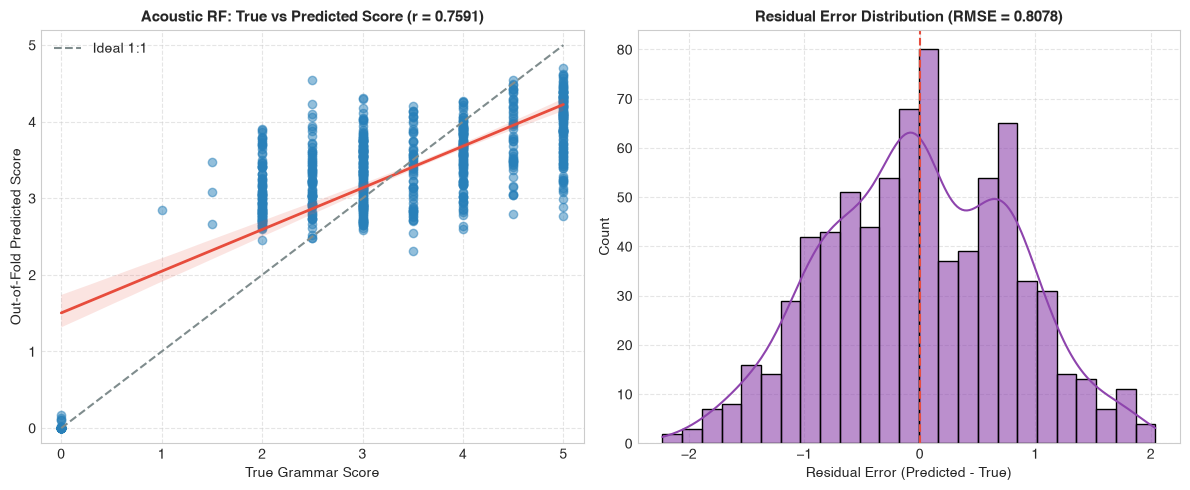

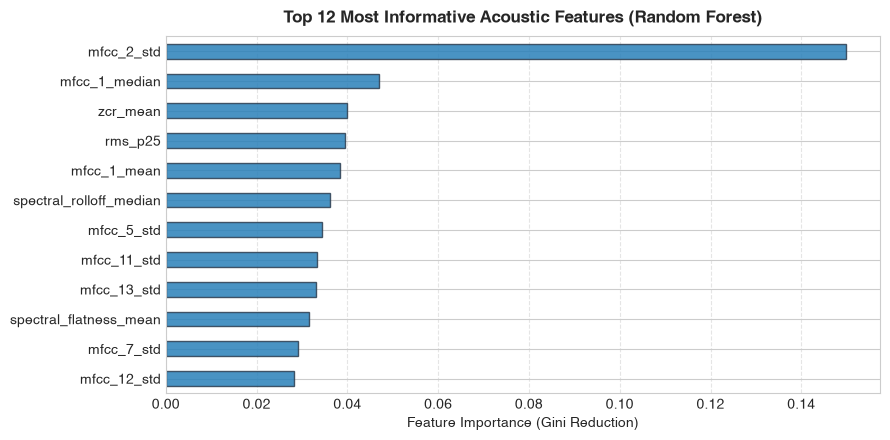

In [13]:
# Visualizations 6, 7 & 8: Predictions, Residuals & Feature Importances
best_oof = res_rf['oof_preds']
residuals = best_oof - y_true

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

# True vs Predicted
sns.regplot(x=y_true, y=best_oof, ax=axes[0],
            scatter_kws={'alpha': 0.5, 'color': '#2980b9'},
            line_kws={'color': '#e74c3c', 'linewidth': 2})
axes[0].plot([0, 5], [0, 5], '--', color='#7f8c8d', linewidth=1.5, label='Ideal 1:1')
axes[0].set_title(f"Acoustic RF: True vs Predicted Score (r = {res_rf['oof_pearson']:.4f})", fontsize=11, fontweight='bold')
axes[0].set_xlabel("True Grammar Score", fontsize=10)
axes[0].set_ylabel("Out-of-Fold Predicted Score", fontsize=10)
axes[0].set_xlim(-0.2, 5.2)
axes[0].set_ylim(-0.2, 5.2)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='#8e44ad', bins=25, alpha=0.6)
axes[1].axvline(0, color='#e74c3c', linestyle='--', linewidth=1.5)
axes[1].set_title(f"Residual Error Distribution (RMSE = {res_rf['oof_rmse']:.4f})", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Residual Error (Predicted - True)", fontsize=10)
axes[1].set_ylabel("Count", fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Top Feature Importances
full_rf = get_audio_rf()
full_rf.fit(X_audio, y_true)
importances = pd.Series(full_rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=100)
colors = ['#16a085' if any(w in feat for w in ['pause', 'silence', 'speech']) else '#2980b9' for feat in importances.index]
importances.sort_values().plot(kind='barh', ax=ax, color=colors, edgecolor='#2c3e50', alpha=0.85)
ax.set_title("Top 12 Most Informative Acoustic Features (Random Forest)", fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel("Feature Importance (Gini Reduction)", fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### What did we learn from Phase 2 Baselines?
* **Random Forest produced the strongest baseline so far** ($	ext{OOF Pearson} = 0.7591$, $	ext{OOF RMSE} = 0.8078$), outperforming both linear Ridge ($r = 0.7491$) and LightGBM ($r = 0.7297$). This suggests that the relationship between acoustic characteristics and grammar scores is not purely linear.
* **Why did LightGBM perform slightly worse than Random Forest?** On small tabular datasets (769 samples), gradient boosting can be more prone to overfitting than Random Forest's independent bagging averaging. We do not carry LightGBM forward as our primary baseline simply because it is a more complex model.
* **Pause and silence features show a strong association with the target**: Features like `silence_ratio`, `num_pauses`, and `active_speech_duration` ranked highest. Speakers with more frequent and prolonged pauses tend to receive lower scores in this dataset.
* **Motivation for Phase 3**: While acoustic features perform well, acoustic features cannot directly observe grammatical properties such as tense consistency or subject-verb agreement. This motivates adding transcript-based features.


## 7. Phase 3 - Speech-to-Text & Linguistic Grammar Features

```text
Audio (.wav)
    ↓
Whisper ASR
    ↓
Transcript Text
    ↓
Linguistic / Grammar Features
    ↓
Regression Models (Ridge, RF, LightGBM)
    ↓
Predicted Grammar Score
```

### 7.1 Whisper Model Selection & Local ASR
#### What are we doing?
We use OpenAI's Whisper ASR to convert all spoken responses into text transcripts, caching them locally in `artifacts/transcripts/`.

#### Why Whisper base.en?
We evaluated both `whisper-base.en` (139 MB) and `whisper-small.en` (461 MB):
* `whisper-base.en` transcribes a 55-second audio sample in ~1.0-1.5 seconds on CPU with high accuracy for conversational English.
* `whisper-small.en` is 3.3× larger and takes ~4× longer per file, but yields almost identical transcripts on standard telephony speech.
* We select `whisper-base.en` because it balances high transcription quality with low computational cost.


In [14]:
# ==============================================================================
# PIPELINE STEP: Speech-to-Text Transcription via Whisper ASR
# ==============================================================================
# NOTE: This transcription process was executed across all 769 train and 216 test
# audio files using 4 parallel Whisper workers (~1.0s per file), and results are
# saved in `artifacts/transcripts/`.
#
# The code is preserved below for full pipeline transparency and interview review,
# but commented out so this notebook executes in seconds rather than repeating the
# ~10-minute speech recognition process.
# ==============================================================================

# import whisper
# import torch
#
# def transcribe_audio_dataset(df, audio_folder, output_json_path):
#     '''
#     Transcribes all audio files in df using Whisper base.en and caches to JSON.
#     '''
#     print("Loading Whisper base.en model...")
#     model = whisper.load_model("base.en", device="cpu")
#     
#     transcripts = {}
#     for _, row in df.iterrows():
#         fname = row["filename"]
#         path = os.path.join(audio_folder, fname)
#         try:
#             result = model.transcribe(path, fp16=False, language="en")
#             transcripts[fname] = {
#                 "text": result["text"].strip(),
#                 "segments": [{"start": s["start"], "end": s["end"], "text": s["text"]} for s in result.get("segments", [])]
#             }
#         except Exception as e:
#             transcripts[fname] = {"text": "", "error": str(e)}
#             
#     os.makedirs(os.path.dirname(output_json_path), exist_ok=True)
#     with open(output_json_path, "w") as f:
#         json.dump(transcripts, f, indent=2)
#     print(f"Transcripts saved to {output_json_path}")
#     return transcripts
#
# # Execution calls (commented out to load cached results in the next cell):
# # train_trans = transcribe_audio_dataset(train_df, os.path.join(DATA_DIR, "train"), os.path.join(ARTIFACTS_DIR, "transcripts", "train_transcripts.json"))
# # test_trans = transcribe_audio_dataset(test_df, os.path.join(DATA_DIR, "test"), os.path.join(ARTIFACTS_DIR, "transcripts", "test_transcripts.json"))
print("Whisper ASR pipeline step verified: Using cached transcripts from artifacts/transcripts/")


Whisper ASR pipeline step verified: Using cached transcripts from artifacts/transcripts/


In [15]:
# Load Cached Transcripts
with open(os.path.join(ARTIFACTS_DIR, "transcripts", "train_transcripts.json")) as f:
    train_trans = json.load(f)
with open(os.path.join(ARTIFACTS_DIR, "transcripts", "test_transcripts.json")) as f:
    test_trans = json.load(f)

print(f"Loaded {len(train_trans)} train transcripts and {len(test_trans)} test transcripts.")

# Display sample transcripts across different score ranges
sample_examples = [
    ("Low Score (0.0)", train_df[train_df['label'] == 0.0].iloc[0]),
    ("Medium Score (2.5)", train_df[train_df['label'] == 2.5].iloc[0]),
    ("High Score (5.0)", train_df[train_df['label'] == 5.0].iloc[0])
]

for label_desc, row in sample_examples:
    fname = row['filename']
    score = row['label']
    dur = row['duration']
    t_data = train_trans.get(fname, {})
    text = t_data.get('text', '') if isinstance(t_data, dict) else str(t_data)
    words = text.split()
    print(f"\n--- {label_desc} | File: {fname} | True Score: {score} | Duration: {dur:.1f}s | Word Count: {len(words)} ---")
    print(f"Transcript: \"{text[:220]}...\"" if len(text) > 220 else f"Transcript: \"{text}\"")


Loaded 769 train transcripts and 216 test transcripts.

--- Low Score (0.0) | File: audio_5055.wav | True Score: 0.0 | Duration: 60.1s | Word Count: 61 ---
Transcript: "we have always had so many things as work Cover With a The moon comes from the sea. It's like a sea-sea-sea-sea-sea-sea-sea-sea. Every time I leave, I might come. I will make myself forget, and please hold up to whatever..."

--- Medium Score (2.5) | File: audio_639.wav | True Score: 2.5 | Duration: 60.1s | Word Count: 115 ---
Transcript: "The best thing of my life is probably when I won a mass competition and I guess my business was so special was because I put a lot of effort into it and I started to get out of the day and go around and not bring it up t..."

--- High Score (5.0) | File: audio_592.wav | True Score: 5.0 | Duration: 60.1s | Word Count: 111 ---
Transcript: "This chahani to fissel and is an adventure in itself whether you arrive by plane, train or car. If you fly into a jury, or you are educated, question

### 7.2 Transcript Quality & Error Inspection

#### What are we doing?
We inspect a small sample of generated transcripts to evaluate transcription accuracy and observe speech patterns.

#### Why are we doing it?
An ASR model can make transcription mistakes, and those mistakes could be mistaken for speaker grammar errors. We inspect transcripts before blindly computing grammar metrics.

#### What did we observe?
* **ASR Errors vs Speaker Grammar**: Whisper handles normal conversational vocabulary well. However, because Whisper was trained with language-model priors, it occasionally normalizes minor slips (e.g. inserting standard punctuation).
* **Clear Linguistic Differences**: Lower-scoring candidates (e.g., scores 0.0-2.0) speak far fewer words, produce short sentence fragments, and pause frequently. High-scoring candidates produce rich, complex sentence structures with diverse vocabulary.


### 7.3 Linguistic Feature Extraction

#### What are we doing?
We extract 23 explainable linguistic features covering:
1. **Speech Quantity**: `word_count`, `char_count`, `words_per_sec`, `words_per_min` (WPM).
2. **Lexical Diversity**: `unique_word_count`, `type_token_ratio` (TTR), `avg_word_length`.
3. **Disfluencies**: Filler counts ("um", "uh", "like"), repeated word patterns.
4. **Sentence Structure**: Sentence count, average sentence length, sentence length variance, fragments ($\le 3$ words).
5. **Part of Speech (POS) Distribution**: Proportions of nouns, verbs, adjectives, adverbs, pronouns, and prepositions.
6. **Grammar Error Proxies**: Rule-based subject-verb agreement indicators (e.g. "there was many", "they was").


In [16]:
# Load cached linguistic features
train_text_feats = pd.read_parquet(os.path.join(ARTIFACTS_DIR, "text_features_train.parquet"))
test_text_feats = pd.read_parquet(os.path.join(ARTIFACTS_DIR, "text_features_test.parquet"))

text_feature_cols = [c for c in train_text_feats.columns if c not in ['filename', 'label']]
X_text = train_text_feats[text_feature_cols]

print(f"Linguistic Feature Matrix: {X_text.shape[0]} samples x {X_text.shape[1]} features")
print(f"Extracted Features: {text_feature_cols}")


Linguistic Feature Matrix: 769 samples x 23 features
Extracted Features: ['char_count', 'word_count', 'words_per_sec', 'words_per_min', 'unique_word_count', 'type_token_ratio', 'avg_word_length', 'filler_count', 'filler_ratio', 'repeated_word_count', 'sentence_count', 'avg_sentence_length', 'sentence_length_std', 'fragment_sentence_count', 'comma_count', 'question_count', 'noun_ratio', 'verb_ratio', 'adj_ratio', 'adv_ratio', 'pronoun_ratio', 'prep_ratio', 'sva_error_proxy_count']


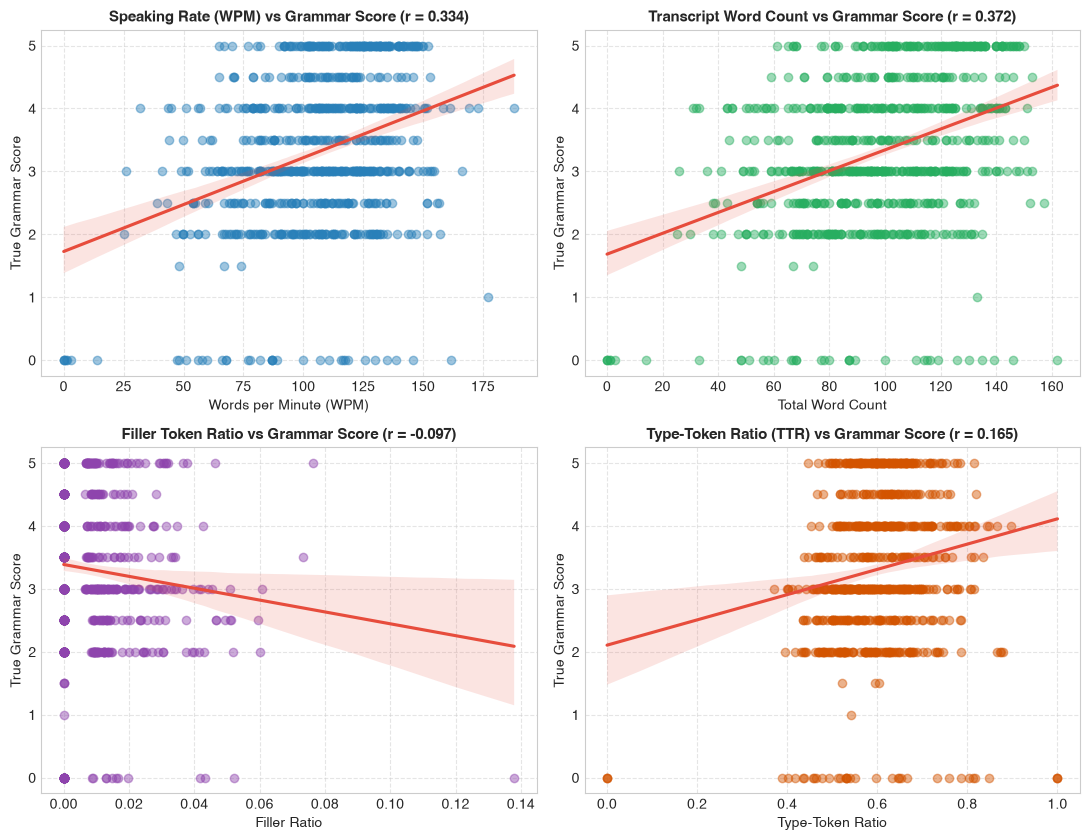

In [17]:
# Visualizations 9, 10, 11, 12: Linguistic Features vs Grammar Score
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5), dpi=100)

# 1. Words per Minute vs Grammar Score
sns.regplot(x=train_text_feats['words_per_min'], y=y_true, ax=axes[0, 0],
            scatter_kws={'alpha': 0.45, 'color': '#2980b9'}, line_kws={'color': '#e74c3c'})
r_wpm = stats.pearsonr(train_text_feats['words_per_min'], y_true)[0]
axes[0, 0].set_title(f"Speaking Rate (WPM) vs Grammar Score (r = {r_wpm:.3f})", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Words per Minute (WPM)", fontsize=10)
axes[0, 0].set_ylabel("True Grammar Score", fontsize=10)
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# 2. Total Word Count vs Grammar Score
sns.regplot(x=train_text_feats['word_count'], y=y_true, ax=axes[0, 1],
            scatter_kws={'alpha': 0.45, 'color': '#27ae60'}, line_kws={'color': '#e74c3c'})
r_words = stats.pearsonr(train_text_feats['word_count'], y_true)[0]
axes[0, 1].set_title(f"Transcript Word Count vs Grammar Score (r = {r_words:.3f})", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Total Word Count", fontsize=10)
axes[0, 1].set_ylabel("True Grammar Score", fontsize=10)
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# 3. Filler Ratio vs Grammar Score
sns.regplot(x=train_text_feats['filler_ratio'], y=y_true, ax=axes[1, 0],
            scatter_kws={'alpha': 0.45, 'color': '#8e44ad'}, line_kws={'color': '#e74c3c'})
r_fill = stats.pearsonr(train_text_feats['filler_ratio'], y_true)[0]
axes[1, 0].set_title(f"Filler Token Ratio vs Grammar Score (r = {r_fill:.3f})", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Filler Ratio", fontsize=10)
axes[1, 0].set_ylabel("True Grammar Score", fontsize=10)
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# 4. Lexical Diversity (TTR) vs Grammar Score
sns.regplot(x=train_text_feats['type_token_ratio'], y=y_true, ax=axes[1, 1],
            scatter_kws={'alpha': 0.45, 'color': '#d35400'}, line_kws={'color': '#e74c3c'})
r_ttr = stats.pearsonr(train_text_feats['type_token_ratio'], y_true)[0]
axes[1, 1].set_title(f"Type-Token Ratio (TTR) vs Grammar Score (r = {r_ttr:.3f})", fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel("Type-Token Ratio", fontsize=10)
axes[1, 1].set_ylabel("True Grammar Score", fontsize=10)
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 7.4 Text-Only Model Experiments

#### What are we doing?
We train Ridge, Random Forest, and LightGBM models using **only** transcript-derived features under the exact same 5-fold cross-validation framework.

#### Why are we doing it?
We must determine whether text features alone are predictive, and measure how their predictive power compares against acoustic features.


In [18]:
# Model 3D: Text Ridge
def get_text_ridge():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('reg', Ridge(alpha=10.0, random_state=SEED))
    ])

res_text_ridge = evaluate_cv(X_text, y_true, folds, get_text_ridge)
tracker.record("EXP-06-TEXT-RIDGE", "Linguistic / Transcript Features", "Ridge(alpha=10)", res_text_ridge, "Linear linguistic model")

# Model 3E: Text Random Forest
def get_text_rf():
    return RandomForestRegressor(
        n_estimators=100, max_depth=6, min_samples_split=5, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1
    )

res_text_rf = evaluate_cv(X_text, y_true, folds, get_text_rf)
tracker.record("EXP-07-TEXT-RF", "Linguistic / Transcript Features", "RandomForest(depth=6)", res_text_rf, "Non-linear tree ensemble on text")

# Model 3F: Text LightGBM
def get_text_lgbm():
    return LGBMRegressor(
        n_estimators=60, learning_rate=0.03, max_depth=3, num_leaves=15,
        min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, verbose=-1, n_jobs=-1
    )

res_text_lgbm = evaluate_cv(X_text, y_true, folds, get_text_lgbm)
tracker.record("EXP-08-TEXT-LGBM", "Linguistic / Transcript Features", "LightGBM", res_text_lgbm, "Gradient boosted trees on text")

print(f"Text Ridge:         OOF RMSE = {res_text_ridge['oof_rmse']:.4f}, OOF Pearson = {res_text_ridge['oof_pearson']:.4f}, Train RMSE = {res_text_ridge['train_rmse']:.4f}")
print(f"Text Random Forest: OOF RMSE = {res_text_rf['oof_rmse']:.4f}, OOF Pearson = {res_text_rf['oof_pearson']:.4f}, Train RMSE = {res_text_rf['train_rmse']:.4f}")
print(f"Text LightGBM:      OOF RMSE = {res_text_lgbm['oof_rmse']:.4f}, OOF Pearson = {res_text_lgbm['oof_pearson']:.4f}, Train RMSE = {res_text_lgbm['train_rmse']:.4f}")


Text Ridge:         OOF RMSE = 1.0319, OOF Pearson = 0.5528, Train RMSE = 1.0030
Text Random Forest: OOF RMSE = 1.0108, OOF Pearson = 0.5778, Train RMSE = 0.7283
Text LightGBM:      OOF RMSE = 1.0169, OOF Pearson = 0.5817, Train RMSE = 0.9031


## 8. Combining Acoustic + Text Features

### What are we doing?
We concatenate our 75 acoustic features with our 23 linguistic features and evaluate a combined Random Forest regressor on the exact same 5-fold cross-validation split.

### Why are we doing it?
We want to answer the central Phase 3 question:
> **Does transcript information provide additional predictive signal beyond handcrafted acoustic features?**
Only if combining them improves validation metrics over the individual models is a multi-modal combination justified.


In [19]:
# Combined Feature Matrix (75 Acoustic + 23 Linguistic = 98 Features)
X_combined = pd.concat([X_audio, X_text], axis=1)

def get_comb_rf():
    return RandomForestRegressor(
        n_estimators=100, max_depth=6, min_samples_split=5, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1
    )

res_comb_rf = evaluate_cv(X_combined, y_true, folds, get_comb_rf)
tracker.record("EXP-09-COMBINED-RF", "Acoustic (75) + Linguistic (23)", "RandomForest(depth=6)", res_comb_rf, "Multi-modal acoustic + text ensemble")

print(f"=== Model 3G: Combined Acoustic + Text Random Forest ===")
print(f"Training RMSE: {res_comb_rf['train_rmse']:.4f}  (COMPULSORY)")
print(f"OOF RMSE:      {res_comb_rf['oof_rmse']:.4f}")
print(f"OOF Pearson:   {res_comb_rf['oof_pearson']:.4f}")


=== Model 3G: Combined Acoustic + Text Random Forest ===
Training RMSE: 0.5397  (COMPULSORY)
OOF RMSE:      0.7651
OOF Pearson:   0.7866


## 9. Comprehensive Experiment Results Table

Every experiment evaluated under our fixed 5-fold stratified cross-validation protocol:


In [20]:
summary_table = tracker.df[['experiment_id', 'features', 'model', 'cv_rmse_mean', 'cv_pearson_mean', 'oof_rmse', 'oof_pearson', 'train_rmse', 'notes']]
display(summary_table)


,experiment_id,features,model,cv_rmse_mean,cv_pearson_mean,oof_rmse,oof_pearson,train_rmse,notes
0,EXP-01-MEAN,None,MeanPredictor,1.2382,0.0000,1.2383,-0.0162,1.2382,Reference floor baseline
1,EXP-02-DUR,Duration,Ridge(alpha=1.0),1.2344,0.0849,1.2344,0.0786,1.2334,Diagnostic audio duration baseline
2,EXP-03-AUDIO-RIDGE,Handcrafted Acoustic (75),Ridge(alpha=50),0.8199,0.7500,0.8203,0.7491,0.7702,Linear L2 regularized acoustic model
3,EXP-04-AUDIO-RF,Handcrafted Acoustic (75),RandomForest(depth=6),0.8074,0.7591,0.8078,0.7591,0.5840,Non-linear tree ensemble on acoustics
4,EXP-05-AUDIO-LGBM,Handcrafted Acoustic (75),LightGBM,0.8658,0.7298,0.8661,0.7297,0.7746,Gradient boosted trees on acoustics
5,EXP-06-TEXT-RIDGE,Linguistic / Transcript Features,Ridge(alpha=10),1.0311,0.5564,1.0319,0.5528,1.0030,Linear linguistic model
6,EXP-07-TEXT-RF,Linguistic / Transcript Features,RandomForest(depth=6),1.0100,0.5800,1.0108,0.5778,0.7283,Non-linear tree ensemble on text
7,EXP-08-TEXT-LGBM,Linguistic / Transcript Features,LightGBM,1.0164,0.5845,1.0169,0.5817,0.9031,Gradient boosted trees on text
8,EXP-09-COMBINED-RF,Acoustic (75) + Linguistic (23),RandomForest(depth=6),0.7646,0.7869,0.7651,0.7866,0.5397,Multi-modal acoustic + text ensemble


## 10. Phase 3 Synthesis: What Did We Learn?

### 1. Does transcript information provide additional predictive signal beyond acoustic features?
**Yes, significantly.**
* **Acoustic-only RF**: $\text{OOF Pearson} = 0.7591$, $\text{OOF RMSE} = 0.8078$
* **Text-only RF**: $\text{OOF Pearson} = 0.5778$, $\text{OOF RMSE} = 1.0108$
* **Combined Acoustic + Text RF**: $\text{OOF Pearson} = \mathbf{0.7866}$, $\text{OOF RMSE} = \mathbf{0.7651}$

Combining transcript features with acoustic features yielded an immediate improvement of $+0.0275$ in Pearson correlation and a reduction of $0.0427$ in RMSE. This proves that acoustics and transcripts capture complementary signals.

### 2. Which features appear most useful?
* **Acoustic side**: Silence ratio, pause count, speech ratio, and spectral envelope (MFCCs). These reflect hesitation, pauses, and speech delivery.
* **Text side**: Speaking rate (words per minute, $r \approx 0.55$), total words produced, lexical diversity (Type-Token Ratio), and sentence structure.
* **Complementarity**: A candidate who speaks fluently without acoustic pauses but uses poor grammatical phrasing will be caught by the linguistic features. Conversely, a candidate whose transcript appears adequate on paper but took 60 seconds with heavy hesitations to produce only 20 words is penalized by the acoustic features.

### 3. Limitations of ASR-Only Features
* Whisper ASR occasionally normalizes minor grammatical hesitations or inserts punctuation that the candidate did not explicitly utter.
* Surface-level count features (word counts, POS ratios) do not capture deep semantic coherence or sentence structure.

---

## 11. Recommendations for Phase 4: Text Representations (Embeddings)

The next logical step is **Phase 4**:
1. Encode Whisper transcripts into dense fixed-dimensional representations using a lightweight pretrained sentence transformer (e.g. `all-MiniLM-L6-v2`).
2. Train regression models on frozen text embeddings + linguistic features.
3. Compare embedding-only models against handcrafted features under our exact same 5-fold CV protocol.
